In [1]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 7.1 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1


In [2]:
from google.colab import userdata
from roboflow import Roboflow

# gunakan roboflow private api key sendiri
api_key = userdata.get('ROBOFLOW_API_KEY')

rf = Roboflow(api_key=api_key)
project = rf.workspace("hprivs").project("packages-iepao")
version = project.version(15)
dataset = version.download("yolov12")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to packages-15 in yolov12:: 100%|██████████| 3011/3011 [00:00<00:00, 5134.62it/s]


In [3]:
import torch
if torch.cuda.is_available():
    print(f"CUDA available: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available.")

CUDA available: Tesla T4


In [5]:
from ultralytics import YOLO

model = YOLO("/content/yolov12n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    name="yolov12n_packages_exp1",
    plots=True,
    patience=8,
    save=True
)

Ultralytics 8.4.127 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/packages-15/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolov12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov12n_packages_ex

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a4b11393230>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [6]:
metrics = model.val()
print(f"mAP@50: {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.127 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,526,971 parameters, 0 gradients, 6.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1638.8±648.7 MB/s, size: 53.0 KB)
val: Scanning /content/packages-15/valid/labels.cache... 453 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 453/453 158.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.7it/s 7.8s
                   all        453       1424        0.7      0.563       0.64      0.425
Speed: 1.7ms preprocess, 7.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50: 0.6405
mAP@50-95: 0.4247


In [7]:
best_model_path = "runs/detect/yolov12n_packages_exp1/weights/best.pt"
best_model = YOLO(best_model_path)
best_model.model.names[0] = "packages"

results = best_model.predict(
    source=f"{dataset.location}/valid/images",
    save=True,
    conf=0.4
)


image 1/453 /content/packages-15/valid/images/-E9-98-B2-E6-BD-AE-E7-BA-B8-E7-AE-B1_jpg.rf.898d141dc56c2b5fc9792c137eeddf3b.jpg: 480x640 1 packages, 12.0ms
image 2/453 /content/packages-15/valid/images/01f96c563dc9f832f87512f6ecf309-jpg-1_jpg.rf.3f99b5b0aebb4e570c5a509f947f2946.jpg: 640x640 3 packagess, 16.6ms
image 3/453 /content/packages-15/valid/images/094210271_png.rf.8aa0500be1573c1e2964dbed76b79ad5.jpg: 640x544 1 packages, 88.2ms
image 4/453 /content/packages-15/valid/images/0d338744ebf81a4cf189472fd92a6059242d_jpg.rf.b57ea86f95fb34f4edf73be7bdfc2af0.jpg: 480x640 3 packagess, 13.7ms
image 5/453 /content/packages-15/valid/images/1-1-768x768_jpg.rf.1b8822f375e05afb1e04b4d9780afce9.jpg: 640x640 2 packagess, 13.2ms
image 6/453 /content/packages-15/valid/images/1-1P321212924X4-lp_jpg.rf.2dad1408be285e904d0efdce9cc49108.jpg: 640x640 1 packages, 13.4ms
image 7/453 /content/packages-15/valid/images/1-200H31K64V24_jpg.rf.feca11adde1556cd25a82b03774339b8.jpg: 480x640 4 packagess, 12.9ms
im

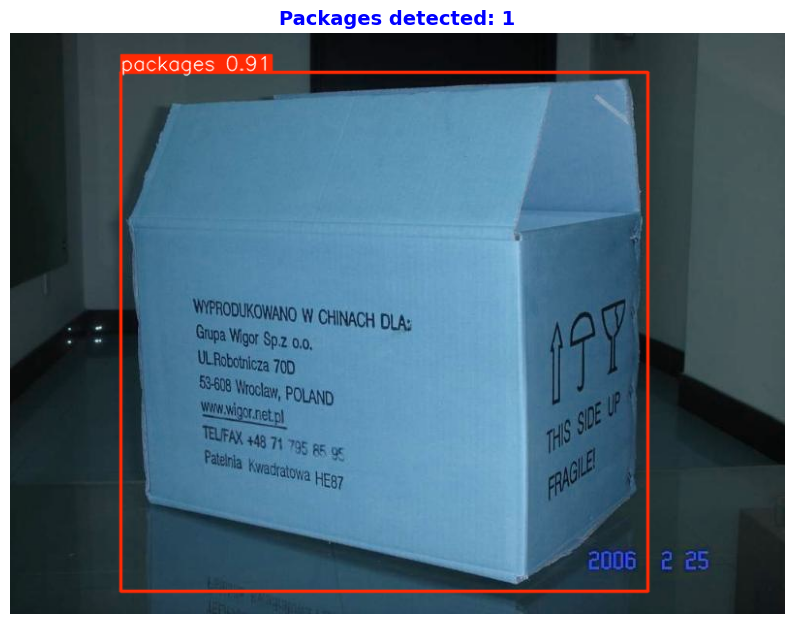

In [8]:
import matplotlib.pyplot as plt

image1 = results[0]
img = image1.plot()

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f"Packages detected: {len(image1.boxes)}", fontsize=14, color='blue', fontweight='bold')
plt.axis('off')
plt.show()


image 1/1 /content/IMG_20260810_134631.jpg: 640x480 1 packages, 13.7ms
Speed: 3.2ms preprocess, 13.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


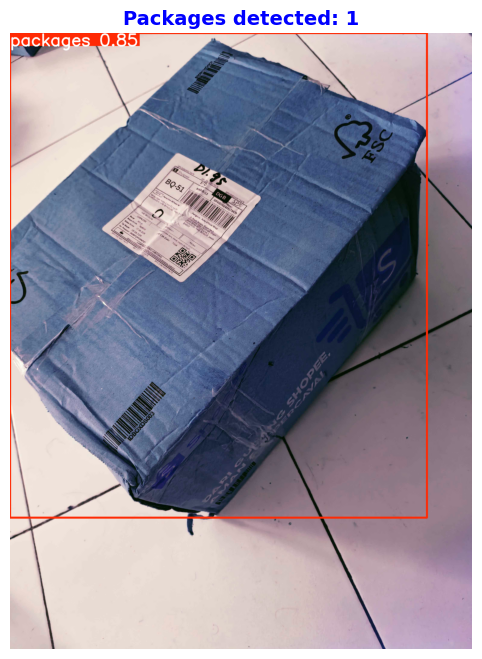

In [9]:
test_sample = best_model.predict(
    source="/content/IMG_20260810_134631.jpg",
    conf=0.4
)

img = test_sample[0].plot()

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f"Packages detected: {len(test_sample[0].boxes)}", fontsize=14, color='blue', fontweight='bold')
plt.axis('off')
plt.show()


image 1/1 /content/POD_MultiplePackages.jpg: 640x640 7 packagess, 21.8ms
Speed: 5.2ms preprocess, 21.8ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


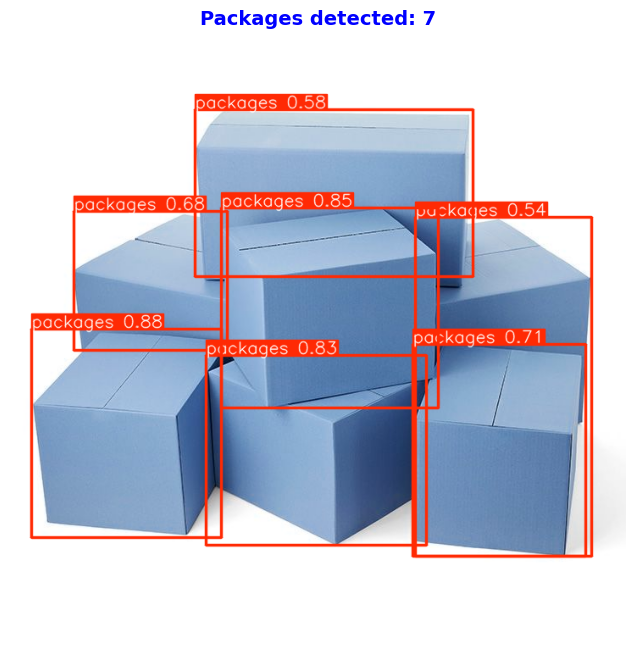

In [10]:
test_sample2 = best_model.predict(
    source="/content/POD_MultiplePackages.jpg",
    conf=0.4,
)

img = test_sample2[0].plot()

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f"Packages detected: {len(test_sample2[0].boxes)}", fontsize=14, color='blue', fontweight='bold')
plt.axis('off')
plt.show()